#Proyecto Data Science - Parte III: Prediccion de volumen operativo en Contact Center     

## Abstract

El presente proyecto enfoca su análisis en un dataset anonimizado de las llamadas que ingresan (inbound) al Contact Center de una empresa de Seguridad, Videovigilancia y Control de Acceso.

El equipo de trabajo de Accesos divide su operativa en cuatro turnos que cambia cada seis horas (Madrugada: 00:00 - 05:59; Mañana: 06:00 - 11:59; Tarde: 12:00 - 17:59; Noche: 18:00 - 23:59). Esto implica que la mayoría de los operadores trabaja jornadas de seis horas, y unos pocos de cuatro horas.

El dataset originado de la plataforma de gestión de llamadas contiene identificadores y nombres anonimizados para los operadores y edificios; fecha y hora de la llamada ocurrida; estado de la llamada (contestada, no contestada); tiempo promedio que transcurre hasta que una llamada es atendida por los operadores una vez ingresan a su interno (ASA, Average Speed Of Answer); tiempo de llamada promedio de los operadores (AHT, Average Handle Time); identificador del operador que atendió la llamada (id_turno, sector al que pertenece y rol que cumple); y tres últimas columnas que marcan SI o NO dependiendo de la naturaleza de la llamada si fuese outbound (si su destino es un intercom, teléfono fijo/celular o un altoparlante o horn utilizado para disuasiones en eventos de seguridad).

A partir del análisis de este dataset se busca estudiar la relación existente entre los diferentes indicadores en cada uno de los turnos así como entender cómo varían estos indicadores según el día de la semana y la hora del dia donde ocurre la llamada propiamente dicha. Una vez identifiquemos estos patrones de demanda operativa se buscará optimizar la gestión de recursos, anticipar cambios en la carga de trabajo y, a raíz de esto, mejorar la calidad del servicio brindado.

En base al análisis exploratorio realizado previamente (ProyectoDSParteI), se pudieron identificar patrones horarios y diferencias operativas entre turnos.

En esta nueva etapa, se busca construir un modelo predictivo que permita anticipar el volumen de llamadas entrantes por hora en base a variables como el tiempo de atención promedio (AHT), el tiempo de espera (ASA), el turno del operador y la franja horaria.





      


## Objetivo

El objetivo del presente proyecto se trata de predecir el número de llamadas entrantes (`CantidadLlamadas`) a un Contact Center, basandonos en variables como la hora del dia donde ocurre (`Hora`); la duracion promedio de llamada (`AHT`), la demora en atención (`ASA`) y si la llamada ocurre entre semana o durante el fin de semana (`fin_de_semana`).

## Importacion de librerias

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate, train_test_split
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

## Carga de dataset

In [52]:
# Cargamos el dataset y lo leemos con Pandas para tener una visualización de las primeras 5 filas
df = pd.read_csv('https://raw.githubusercontent.com/raven-flp/proyecto.coder/refs/heads/main/dataset_anonimizado.csv')
df.head()

,id_edificio,id_operador,fecha_hora,nombre_origen,nombre_destino,estado,sonando,hablando,totales,id_turno,sector,rol,intercom,fijo_cel,altoparlante
0,27,1,2025-03-01 0:00:27,001 - Edificio 1 (00001),Operador 1 (10000),contestadas,0,5,0,0,Cola,Cola,NaN,NO,NO
1,27,77,2025-03-01 0:00:27,001 - Edificio 1 (00001),Operador 2 (10001),contestadas,5,14,24,1,Centro Control,Monitoreo,NaN,NO,NO
2,438,1,2025-03-01 0:00:48,002 - Edificio 2 (00002),Operador 1 (10000),contestadas,0,2,0,0,Cola,Cola,NaN,NO,NO
3,438,12,2025-03-01 0:00:48,002 - Edificio 2 (00002),Operador 3 (10002),contestadas,2,16,20,1,Centro Control,Monitoreo,NaN,NO,NO
4,289,1,2025-03-01 0:02:58,003 - Edificio 3 (00003),Operador 1 (10000),contestadas,0,6,0,0,Cola,Cola,NaN,NO,NO


## Hipótesis

**Hipótesis Nula (H0)**: A partir de las variables disponibles (ASA, AHT, hora, etc.) no es posible predecir el número de llamadas que ingresarán al Contact Center de Accesos con un rendimiento significativamente mejor que un modelo base, como predecir siempre el promedio de llamadas.

**Hipótesis Alternativa (H1)**: A partir de las variables disponibles es posible construir un modelo de regresión (RandomForestRegressor) que prediga el número de llamadas que ingresarán al Contact Center de Accesos con coeficiente de determinación (R²) altamente superior a 0 y un Error Absoluto Medio (MAE) bajo.


## Descripción de los tipos de datos

Las columnas que contienen información numérica como 'sonando', 'hablando', 'totales', etc, fueron reconocidos correctamente como int64. A partir de esto fue posible realizar cálculos matemáticos y estadísticos sin inconvenientes. La columna relacionada con fechas y horas como fecha_hora fue convertida a formato datetime64 para facilitar el análisis basado en el tiempo, como cálculos de promedios por hora, dia o mes. Fue de este modo que definimos los cuatro turnos en base a la hora que podemos extraer de fecha_hora usando Pandas. Las columnas que almacenan cadenas de texto como 'intercom' o 'nombre_destino' fueron tratadas como object permitiéndonos realizar manipulaciones cuando fuese necesario.

### Razón para excluir ciertos operadores y registros en los cálculos

Durante el proceso de limpieza y preparación de los datos se excluyeron ciertos operadores y registros que no son de importancia en el presente análisis. Al tener conocimiento de como funciona la plataforma de telecomunicaciones y como estan configurados los operadores sabemos que las llamadas con id_operador <= 1 son de operadores de testeo y un operador para visualizar la cola de llamadas (Q), los cuales no tienen impacto en las mediciones que queremos realizar. A su vez excluímos los operadores con id_turno == 5, ya que estos pertenecen a otro sector y no son el objeto de análisis de este proyecto. Por último excluímos registros de los edificios con id_edificio == 0, ya que referían a comunicaciones dentro de la empresa (por fuera del sector de Accesos) y que no tienen importancia para el presente trabajo.

### Transformación de datos

A fin de realizar un análisis mas efectivo se realizaron diversas transformaciones sobre el dataframe. Una de las principales fue la conversión de la columna fecha_hora, inicialmente en formato object, a un formato datetime. Esto perimitió desglosar fecha_hora en sus componentes individuales usando Pandas, lo que facilitó la segmentación de los datos en horas, dias, turnos para calcular de forma mas precisa el ASA y el AHT. A su vez se crearon nuevas columnas como dia_semana que permite evaluar el comportamiento de las metricas seleccionadas por dia de la semana y detectar asi patrones que puedan llevar a oportunidades de mejora en la operativa.

In [53]:
# 'fecha_hora' no esta en formato datetime por lo que no vamos a poder realizar operaciones con ella hasta transformarla.
df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])

### Manejo de datos vacíos, nulos y NaN

In [54]:
# Visualizamos rapidamente con este análisis exploratorio rapido si tenemos NaN's y los diferentes tipos de datos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199110 entries, 0 to 199109
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id_edificio     199110 non-null  int64         
 1   id_operador     199110 non-null  int64         
 2   fecha_hora      199110 non-null  datetime64[ns]
 3   nombre_origen   199110 non-null  object        
 4   nombre_destino  199110 non-null  object        
 5   estado          199110 non-null  object        
 6   sonando         199110 non-null  int64         
 7   hablando        199110 non-null  int64         
 8   totales         199110 non-null  int64         
 9   id_turno        199110 non-null  int64         
 10  sector          199110 non-null  object        
 11  rol             199110 non-null  object        
 12  intercom        0 non-null       float64       
 13  fijo_cel        199110 non-null  object        
 14  altoparlante    199110 non-null  obj

Una de las primeras decisiones en la limpieza de datos fue el manejo de la columna intercom que contenia 100% de valores nulos. Para evitar que estos valores afectaran cualquier tipo de posterior analisis, se decidió reemplazar los valores nulos por "NO" usando Pandas. Al tener conocimiento del funcionamiento de la plataforma utilizada para gestionar las llamadas es posible decidir esto sin muchos inconvenientes ya que si los registros son para llamadas entrantes todos los valores deben ser NO (estas tres columnas -intercom, fijo_cel, altoparlante) marcan SI solamente en casos de llamadas salientes y no es el objeto de estudio en este proyecto.

In [55]:
# Identificamos facilmente que la columna 'intercom' figura totalmente nula por lo que debemos cambiarlo. Elegimos cambiar a 'NO' ya que estamos evaluando llamadas entrantes (inbound) en este análisis
df['intercom'] = df['intercom'].fillna('NO')

# Volvemos a visualizar con db.info si el cambio fue exitoso
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199110 entries, 0 to 199109
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id_edificio     199110 non-null  int64         
 1   id_operador     199110 non-null  int64         
 2   fecha_hora      199110 non-null  datetime64[ns]
 3   nombre_origen   199110 non-null  object        
 4   nombre_destino  199110 non-null  object        
 5   estado          199110 non-null  object        
 6   sonando         199110 non-null  int64         
 7   hablando        199110 non-null  int64         
 8   totales         199110 non-null  int64         
 9   id_turno        199110 non-null  int64         
 10  sector          199110 non-null  object        
 11  rol             199110 non-null  object        
 12  intercom        199110 non-null  object        
 13  fijo_cel        199110 non-null  object        
 14  altoparlante    199110 non-null  obj

## Definición de indicadores y filtro inicial del dataframe

In [56]:
# Creamos filtros necesarios para medir la operativa inbound al contact center y evitar llamadas por fuera de este.
df_filtrado = df[
    (df['id_operador'] > 1) &
    (df['id_turno'] != 5) &
    (df['id_edificio'] != 0) &
    (df['estado'] == "contestadas")
].copy()

# Creamos nuevas variables temporales a partir de fecha_hora y creamos una lista con los turnos a partir del id_turno
df_filtrado['fecha_hora'] = pd.to_datetime(df_filtrado['fecha_hora'])
df_filtrado['fecha']      = df_filtrado['fecha_hora'].dt.date
df_filtrado['hora']       = df_filtrado['fecha_hora'].dt.hour
df_filtrado['dia_semana'] = df_filtrado['fecha_hora'].dt.day_name()
df_filtrado['fin_de_semana'] = (df_filtrado['fecha_hora'].dt.dayofweek >= 5).astype(int)
df_filtrado['turno'] = df_filtrado['id_turno'].map({
    1: 'Madrugada',
    2: 'Mañana',
    3: 'Tarde',
    4: 'Noche'
})

In [57]:
df_filtrado.head()

,id_edificio,id_operador,fecha_hora,nombre_origen,nombre_destino,estado,sonando,hablando,totales,id_turno,sector,rol,intercom,fijo_cel,altoparlante,fecha,hora,dia_semana,fin_de_semana,turno
1,27,77,2025-03-01 00:00:27,001 - Edificio 1 (00001),Operador 2 (10001),contestadas,5,14,24,1,Centro Control,Monitoreo,NO,NO,NO,2025-03-01,0,Saturday,1,Madrugada
3,438,12,2025-03-01 00:00:48,002 - Edificio 2 (00002),Operador 3 (10002),contestadas,2,16,20,1,Centro Control,Monitoreo,NO,NO,NO,2025-03-01,0,Saturday,1,Madrugada
5,289,12,2025-03-01 00:02:58,003 - Edificio 3 (00003),Operador 3 (10002),contestadas,6,45,57,1,Centro Control,Monitoreo,NO,NO,NO,2025-03-01,0,Saturday,1,Madrugada
7,146,77,2025-03-01 00:03:53,004 - Edificio 4 (00004),Operador 2 (10001),contestadas,3,26,32,1,Centro Control,Monitoreo,NO,NO,NO,2025-03-01,0,Saturday,1,Madrugada
9,16,77,2025-03-01 00:05:01,005 - Edificio 5 (00005),Operador 2 (10001),contestadas,3,18,24,1,Centro Control,Monitoreo,NO,NO,NO,2025-03-01,0,Saturday,1,Madrugada


In [58]:
df_filtrado.describe()

,id_edificio,id_operador,fecha_hora,sonando,hablando,totales,id_turno,hora,fin_de_semana
count,93574.000000,93574.000000,93574,93574.000000,93574.000000,93574.000000,93574.000000,93574.000000,93574.000000
mean,204.455960,65.397707,2025-03-17 05:35:29.227017984,1.712666,27.136576,45.138778,3.009030,14.250176,0.219003
min,1.000000,4.000000,2025-03-01 00:00:27,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,92.000000,44.000000,2025-03-10 12:02:46.500000,1.000000,11.000000,19.000000,2.000000,11.000000,0.000000
50%,184.000000,63.000000,2025-03-17 13:53:02.500000,1.000000,16.000000,34.000000,3.000000,14.000000,0.000000
75%,296.000000,88.000000,2025-03-24 17:16:49,2.000000,33.000000,60.000000,4.000000,18.000000,0.000000
max,498.000000,103.000000,2025-03-31 23:51:22,10.000000,10778.000000,10800.000000,6.000000,23.000000,1.000000
std,132.853795,25.118634,NaN,1.897892,46.172829,51.273648,0.962338,4.813060,0.413573


In [59]:
# Luego de un EDA superficial decidimos excluir las columnas del dataframe que no aportaban información significativa (diferentes id's, turno de la llamada, sector, rol, etc)
# El turno esta definido por la hora donde ocurre por lo que no es necesario este tipo de filtrado inicialmente

df_hora = (
    df_filtrado
    .groupby(['fecha', 'hora', 'fin_de_semana'], observed=True)
    .agg(
        AHT=('hablando', 'mean'),
        ASA=('sonando',  'mean'),
        CantidadLlamadas=('id_operador', 'count')
    )
    .reset_index()
)

# Variables predictoras y target

features = ['hora', 'AHT', 'ASA', 'fin_de_semana']
target   = 'CantidadLlamadas'

X = df_hora[features]
y = df_hora[target]


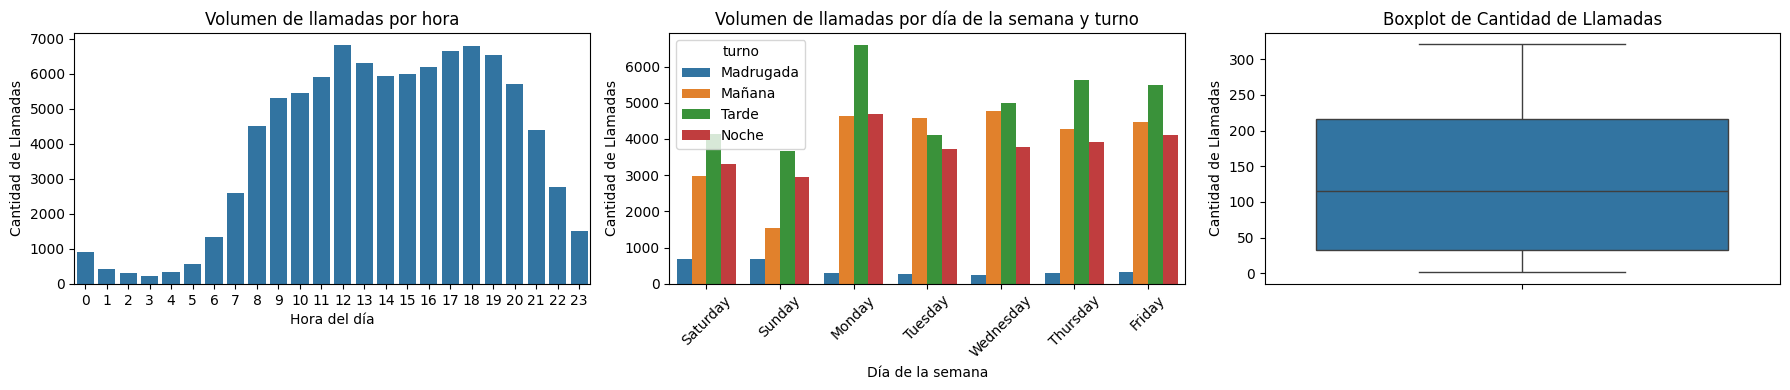

In [60]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

# Countplot de la variable target (Volumen de llamadas por hora)
sns.countplot(data=df_filtrado, x='hora', ax=ax[0])
ax[0].set_title('Volumen de llamadas por hora')
ax[0].set_xlabel('Hora del día')
ax[0].set_ylabel('Cantidad de Llamadas')

# Gráfico de barras por Día de la Semana y Turno
sns.countplot(data=df_filtrado, x='dia_semana', hue='turno', ax=ax[1])
ax[1].set_title('Volumen de llamadas por día de la semana y turno')
ax[1].set_xlabel('Día de la semana')
ax[1].set_ylabel('Cantidad de Llamadas')
ax[1].tick_params(axis='x', rotation=45)

# Boxplot de la cantidad de llamadas por hora
sns.boxplot(data=df_hora, y='CantidadLlamadas', ax=ax[2])
ax[2].set_title('Boxplot de Cantidad de Llamadas')
ax[2].set_ylabel('Cantidad de Llamadas')

plt.tight_layout()
plt.show()


In [61]:
# Descripción de las variables numéricas en nuestro dataframe
df_hora.describe()

,hora,fin_de_semana,AHT,ASA,CantidadLlamadas
count,744.000000,744.000000,744.000000,744.000000,744.000000
mean,11.500000,0.322581,25.229982,2.036084,125.771505
std,6.926843,0.467778,7.154296,0.777970,93.333532
min,0.000000,0.000000,7.000000,0.180180,1.000000
25%,5.750000,0.000000,21.156892,1.526288,32.000000
50%,11.500000,0.000000,25.543158,1.907591,115.000000
75%,17.250000,1.000000,28.898265,2.375000,216.000000
max,23.000000,1.000000,95.000000,5.777778,321.000000


## Matriz de correlación de las variables

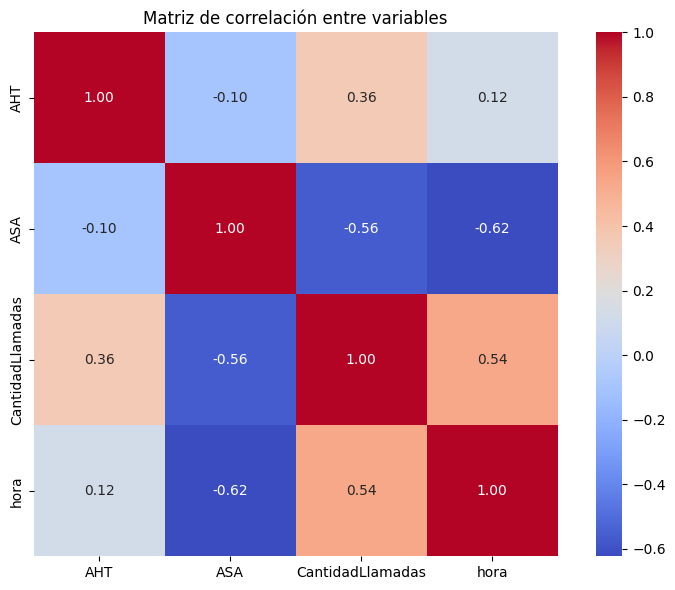

In [62]:
# Seleccionar variables relevantes
variables_correlacion = df_hora[['AHT', 'ASA', 'CantidadLlamadas', 'hora']]

# Calcular la matriz
matriz_correl = variables_correlacion.corr()

# Ploteamos
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correl, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Matriz de correlación entre variables")
plt.tight_layout()
plt.show()

`Hora` tiene la correlación positiva más alta con `CantidadLlamadas`. `AHT` tiene una correlacion positiva y de menor valor. `ASA` tiene una correlación negativa alta.

## Preprocesamiento, Feature Selection, Validación Temporal y Entrenamiento

In [63]:
# Creacion de Pipeline base y Feature Selection

cat_features = ['hora', 'fin_de_semana']
num_features = ['AHT', 'ASA']

preproc = ColumnTransformer(
    [('cat', OneHotEncoder(drop='first'), cat_features),
     ('num', 'passthrough',           num_features)]
)

# Feature selection; Se optó utilizar threshold = 'median' y n_estimators = 250 ya que fueron los valores que dieron mejores resultados en performance del modelo
selector = SelectFromModel(
    RandomForestRegressor(n_estimators=250, random_state=42),
    threshold='median'
)


In [64]:
# Validación temporal y entrenamiento

# TimeSeriesSplit con 5 splits al tratarse de serie temporal
tscv = TimeSeriesSplit(n_splits=5)

# Definir la métrica MAE
mae = make_scorer(mean_absolute_error, greater_is_better=False)

# Crear el modelo RandomForest
modelo = RandomForestRegressor(n_estimators=250, random_state=42)

# Crear el pipeline con preprocesamiento y selección de características
pipe = Pipeline([
    ('prep', preproc),
    ('sel', selector),
    ('model', modelo)
])

# Evaluación con cross-validation
cv = cross_validate(
    pipe, X, y, cv=tscv,
    scoring={'MAE': mae, 'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'},
    n_jobs=-1
)

# Mostrar los resultados
print("Resultados de validación cruzada:")
print(f"MAE: {-cv['test_MAE'].mean():.2f}")
print(f"RMSE: {-cv['test_RMSE'].mean():.2f}")
print(f"R²: {cv['test_R2'].mean():.2f}")

Resultados de validación cruzada:
MAE: 35.30
RMSE: 51.17
R²: 0.70


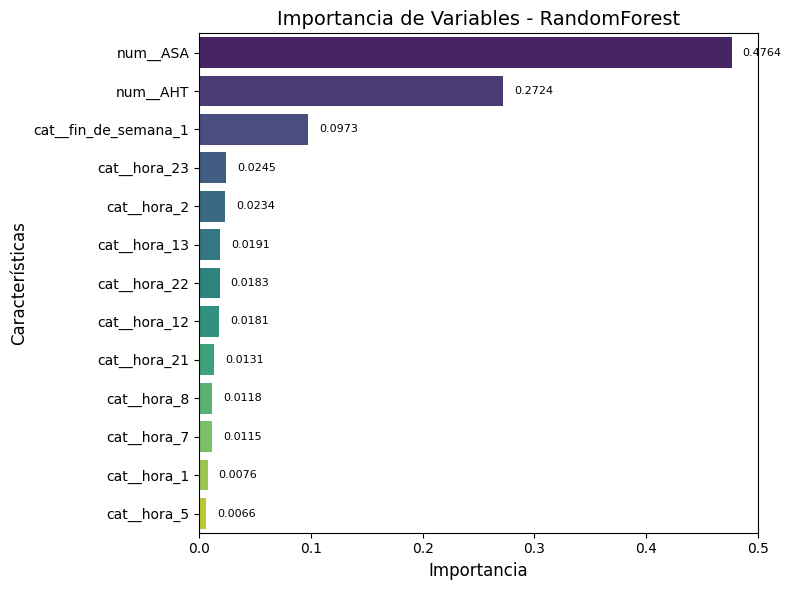

In [65]:
# Pipeline final con el preprocesamiento, feature selection y el modelo
pipe_final = Pipeline([
    ('prep', preproc),
    ('sel', selector),
    ('model', RandomForestRegressor(n_estimators=250, random_state=42))
])

# Entrenamos el modelo final con todo el conjunto de datos
pipe_final.fit(X, y)

# Importancia de las variables; obtenemos los nombres de las características después de la selección
selected_feature_names = pipe_final.named_steps['sel'].get_feature_names_out(pipe_final.named_steps['prep'].get_feature_names_out())

importancias = pd.Series(pipe_final.named_steps['model'].feature_importances_, index=selected_feature_names)\
                 .sort_values(ascending=False)

# Barplot para la importancia de las características
plt.figure(figsize=(8, 6))
sns.barplot(x=importancias, y=importancias.index, palette="viridis", hue=importancias.index)
plt.title('Importancia de Variables - RandomForest', fontsize=14)
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Características', fontsize=12)
for i, v in enumerate(importancias):
    plt.text(v + 0.01, i, f'{v:.4f}', color='black', va='center', fontsize=8)
plt.tight_layout()
plt.show()


## Predicciones vs Valores Reales

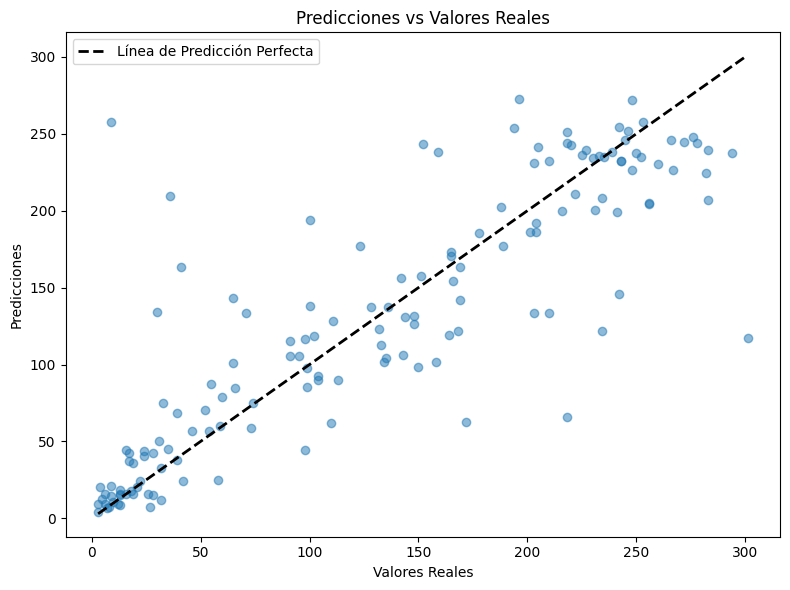

In [66]:
# Dividir los datos para entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Entrenar el pipeline final con los datos de entrenamiento
pipe_final.fit(X_train, y_train)

# Realizar predicciones con los datos de prueba
y_pred = pipe_final.predict(X_test)

# Scatter Plot para Predicciones vs Valores Reales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Línea de Predicción Perfecta')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.legend()
plt.tight_layout()


# Mostrar el gráfico
plt.show()


## Conclusiones y validación de hipótesis

La hipótesis planteada previamente en este proyecto establece que es posible predecir el volumen de llamadas entrantes (`CantidadLlamadas`) a un Contact Center utilizando variables como la hora del día (`hora`), el tiempo de atención promedio (`AHT`), la demora en la atención (`ASA`), y si la llamada ocurre en fin de semana o no. La variable target es la cantidad de llamadas, y se busca evaluar si un modelo de regresión, en este caso un RandomForestRegressor, puede hacer predicciones precisas sobre este volumen.

# Resultados del Modelo

In [67]:
print("Resultados del modelo de regresión RandomForestRegressor:")
print(f"MAE: {-cv['test_MAE'].mean():.2f}")
print(f"RMSE: {-cv['test_RMSE'].mean():.2f}")
print(f"R²: {cv['test_R2'].mean():.2f}")

Resultados del modelo de regresión RandomForestRegressor:
MAE: 35.30
RMSE: 51.17
R²: 0.70


Luego de realizar el análisis y entrenamiento del modelo con las características seleccionadas, los resultados obtenidos fueron los siguientes:

* MAE (Error Absoluto Medio): El modelo presenta un valor de MAE razonablemente bajo (35.3) lo que indica que las predicciones del volumen de llamadas se desvían, en promedio, por una cantidad que es aceptable para la operativa del Contact Center.

* RMSE (Raíz del Error Cuadrático Medio): El RMSE es bajo (51.17), lo cual refleja que el modelo tiene una buena capacidad de predicción y penaliza los errores grandes de manera efectiva.

* R² (Coeficiente de Determinación): El valor de R² es superior a 0.5 (0.7), lo que indica que el modelo es capaz de explicar una proporción significativa de la variabilidad en la cantidad de llamadas.

# Interpretación:


* MAE (Error Absoluto Medio) = 35.30: Esto significa que, en promedio, las predicciones del modelo se desvían por 35.30 llamadas del valor real.

* RMSE (Raíz del Error Cuadrático Medio) = 51.17: Esta métrica penaliza más los errores grandes. El RMSE indica que, en promedio, la desviación de las predicciones más grandes es de 51.17 llamadas. Lo que sugiere que el modelo tiene un buen rendimiento sin errores extremos.

* R² = 0.70: Este valor significa que el modelo es capaz de explicar el 70% de la variabilidad en el volumen de llamadas. En otras palabras, el modelo tiene una buena capacidad para predecir las cantidades de llamadas, ya que un 70% de las fluctuaciones en los datos son explicadas por las variables que hemos utilizado para entrenarlo.


En resumen, el modelo tiene un rendimiento sólido, con un error promedio razonable (MAE), penalizando bien los errores grandes (RMSE) y explicando un alto porcentaje de la variabilidad de las llamadas (R² = 0.70). Basándonos en lo anterior podemos concluir que el modelo puede ser útil para predecir el volumen de llamadas entrantes y optimizar la gestión de recursos en el Contact Center.
   




# Confirmación de la hipótesis

En base a los resultados obtenidos, la **Hipótesis alternativa (H1)** queda validada. El modelo ha demostrado ser eficaz para predecir el volumen de llamadas entrantes, alcanzando un rendimiento satisfactorio en las métricas evaluadas. Los valores de R² y MAE indican que el modelo es más efectivo que un modelo base, y las características seleccionadas contribuyen de manera relevante a la predicción.

Por lo tanto, se rechaza la **Hipótesis nula (H0)**, ya que el modelo es capaz de ofrecer predicciones significativamente mejores que un modelo trivial. Esto sugiere que la implementación de un modelo predictivo basado en características operativas como la hora del día, AHT, ASA y si ocurre en el fin de semana o no, puede ser útil para mejorar la gestión de recursos y la optimización operativa del Contact Center.